# 🔧 HVAC Anomaly Detection — Step 2: Preprocessing
**Input:** `HVAC_NE_EC_19-21.csv`  
**Output:** `X_train.npy`, `X_val.npy`, `X_test.npy` (ready for model)

### What this notebook does
1. Select features from EDA
2. Handle the 183-day data gap → split into 2 periods
3. Reindex to 15-min frequency + interpolate small gaps
4. Normalize with Min-Max (fit on Period 1 only)
5. Create sliding windows (96 steps = 24h)
6. Split into Train / Validation / Test

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120, 'axes.grid':True, 'grid.alpha':0.3,
                     'axes.spines.top':False, 'axes.spines.right':False})
print("✅ Imports OK")

✅ Imports OK


## 1. Load Data & Select Features
From EDA we selected 5 features:
- **T_Supply, T_Return, T_Outdoor, Power** — raw sensors
- **T_delta** — engineered: T_Supply − T_Return (best anomaly signal)

In [2]:
DATA_PATH = 'HVAC_NE_EC_19-21.csv'

df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
df = df.set_index('Timestamp').sort_index()

# Engineer T_delta
df['T_delta'] = df['T_Supply'] - df['T_Return']

SELECTED = ['T_Supply', 'T_Return', 'T_Outdoor', 'Power', 'T_delta']
df = df[SELECTED]

print(f"Shape     : {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Features  : {SELECTED}")
df.head()

Shape     : (33888, 5)
Date range: 2019-10-14 22:00:00+00:00 → 2021-04-14 21:45:00+00:00
Features  : ['T_Supply', 'T_Return', 'T_Outdoor', 'Power', 'T_delta']


,T_Supply,T_Return,T_Outdoor,Power,T_delta
Timestamp,,,,,
2019-10-14 22:00:00+00:00,19.859999,20.469999,20.299999,0.0,-0.610000
2019-10-14 22:15:00+00:00,19.855000,20.430000,20.299999,0.0,-0.575000
2019-10-14 22:30:00+00:00,19.850000,20.410000,20.299999,0.0,-0.560000
2019-10-14 22:45:00+00:00,19.840000,20.379999,20.299999,0.0,-0.539999
2019-10-14 23:00:00+00:00,19.830000,20.350000,20.299999,0.0,-0.520000


## 2. Gap Analysis
Find all time gaps larger than 1 hour.

In [3]:
# Find all gaps > 1h
time_diffs = df.index.to_series().diff()
gaps = time_diffs[time_diffs > pd.Timedelta('1h')]
print("All gaps > 1 hour:")
print(gaps.to_string())

print(f"\nExpected rows @ 15min: {len(pd.date_range(df.index.min(), df.index.max(), freq='15min')):,}")
print(f"Actual rows           : {len(df):,}")
print(f"Missing timestamps    : {len(pd.date_range(df.index.min(), df.index.max(), freq='15min')) - len(df):,}")

All gaps > 1 hour:
Timestamp
2019-10-27 01:00:00+00:00     0 days 01:15:00
2020-03-09 23:00:00+00:00     6 days 00:15:00
2020-03-29 22:00:00+00:00     0 days 23:15:00
2020-10-14 22:00:00+00:00   183 days 00:15:00
2020-10-25 01:00:00+00:00     0 days 01:15:00
2021-01-03 23:00:00+00:00     2 days 00:15:00
2021-01-11 23:00:00+00:00     1 days 00:15:00
2021-03-28 22:00:00+00:00     0 days 23:15:00
2021-04-02 22:00:00+00:00     1 days 00:15:00

Expected rows @ 15min: 52,608
Actual rows           : 33,888
Missing timestamps    : 18,720


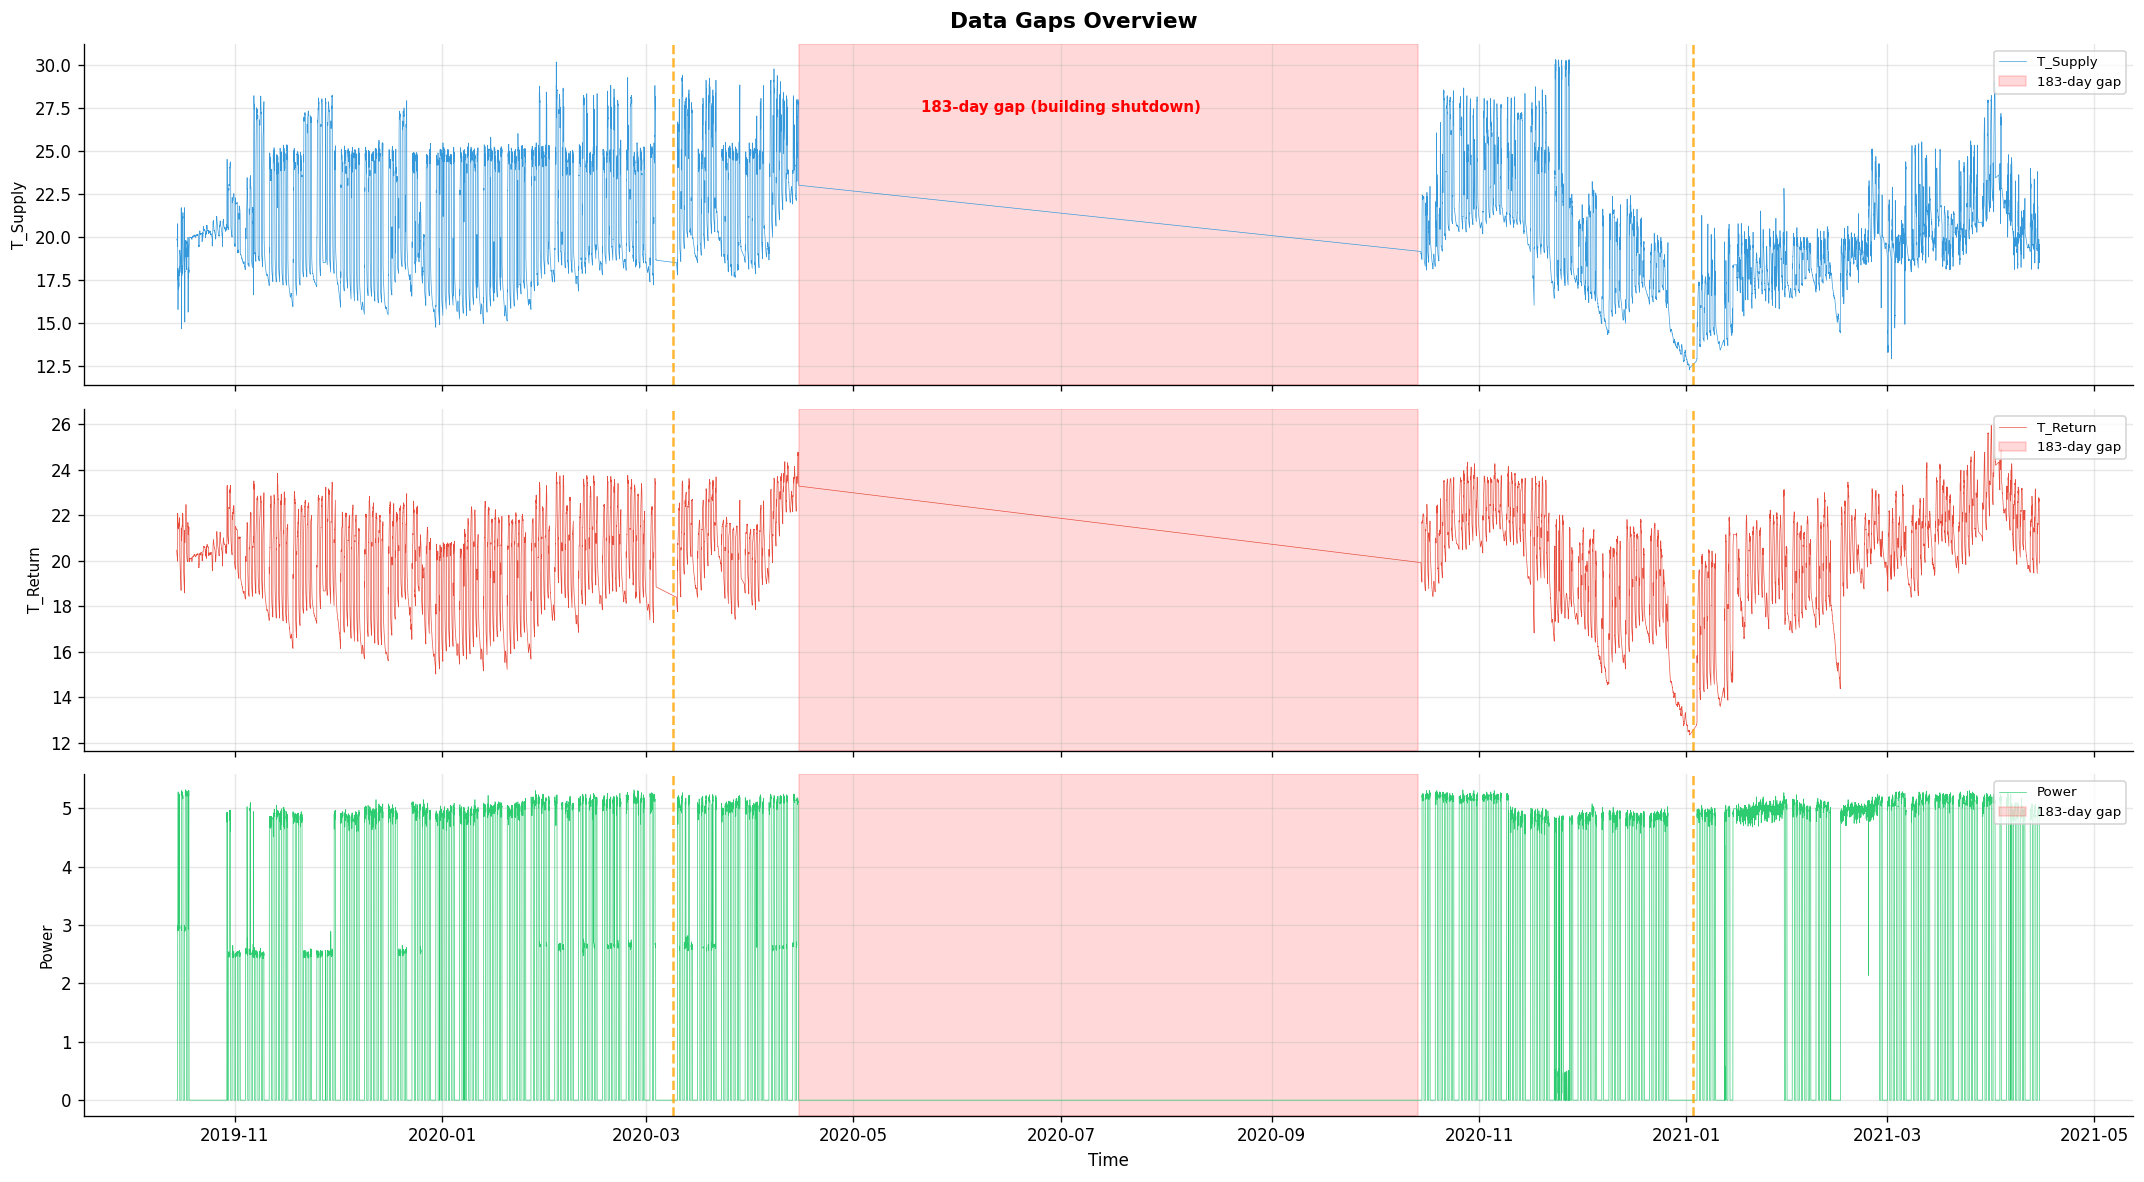

In [4]:
# Visualize gaps
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Data Gaps Overview', fontsize=13, fontweight='bold')

for ax, col, c in zip(axes, ['T_Supply','T_Return','Power'],
                      ['#3498db','#e74c3c','#2ecc71']):
    ax.plot(df.index, df[col], linewidth=0.4, color=c, label=col)
    ax.axvspan(pd.Timestamp('2020-04-15', tz='UTC'),
               pd.Timestamp('2020-10-14', tz='UTC'),
               alpha=0.15, color='red', label='183-day gap')
    for g in [pd.Timestamp('2020-03-09', tz='UTC'),
              pd.Timestamp('2021-01-03', tz='UTC')]:
        ax.axvline(g, color='orange', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_ylabel(col, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')

axes[0].annotate('183-day gap (building shutdown)',
    xy=(pd.Timestamp('2020-07-01', tz='UTC'), df['T_Supply'].max()*0.9),
    fontsize=9, color='red', fontweight='bold', ha='center')
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('01_gaps_issues.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Split Into Two Periods + Reindex
The 183-day gap is too large to interpolate — we split into two independent periods:
- **Period 1:** Oct 2019 – Apr 2020 (pre-shutdown) → **Train + Validation**
- **Period 2:** Oct 2020 – Apr 2021 (post-restart) → **Test** (contains known anomalies)

Smaller gaps (≤ 2h) are filled with linear interpolation.

In [5]:
GAP_SPLIT = pd.Timestamp('2020-04-15', tz='UTC')  # end of Period 1
GAP_END   = pd.Timestamp('2020-10-14', tz='UTC')  # start of Period 2

p1_raw = df[df.index < GAP_SPLIT].copy()
p2_raw = df[df.index >= GAP_END].copy()

def reindex_and_fill(df_period):
    """Reindex to strict 15-min grid, interpolate small gaps (≤ 2h = 8 steps)."""
    full_idx = pd.date_range(df_period.index.min(),
                             df_period.index.max(), freq='15min')
    df_r = df_period.reindex(full_idx)
    df_r = df_r.interpolate(method='linear', limit=8)  # max 2h gap
    df_r = df_r.ffill(limit=4)                          # DST 1h gaps
    return df_r.dropna()

p1 = reindex_and_fill(p1_raw)
p2 = reindex_and_fill(p2_raw)

print(f"Period 1: {p1.index.min().date()} → {p1.index.max().date()}  rows={len(p1):,}")
print(f"Period 2: {p2.index.min().date()} → {p2.index.max().date()}  rows={len(p2):,}")
print(f"P1 missing after fill: {p1.isnull().sum().sum()}")
print(f"P2 missing after fill: {p2.isnull().sum().sum()}")

Period 1: 2019-10-14 → 2020-04-14  rows=16,924
Period 2: 2020-10-14 → 2021-04-14  rows=17,044
P1 missing after fill: 0
P2 missing after fill: 0


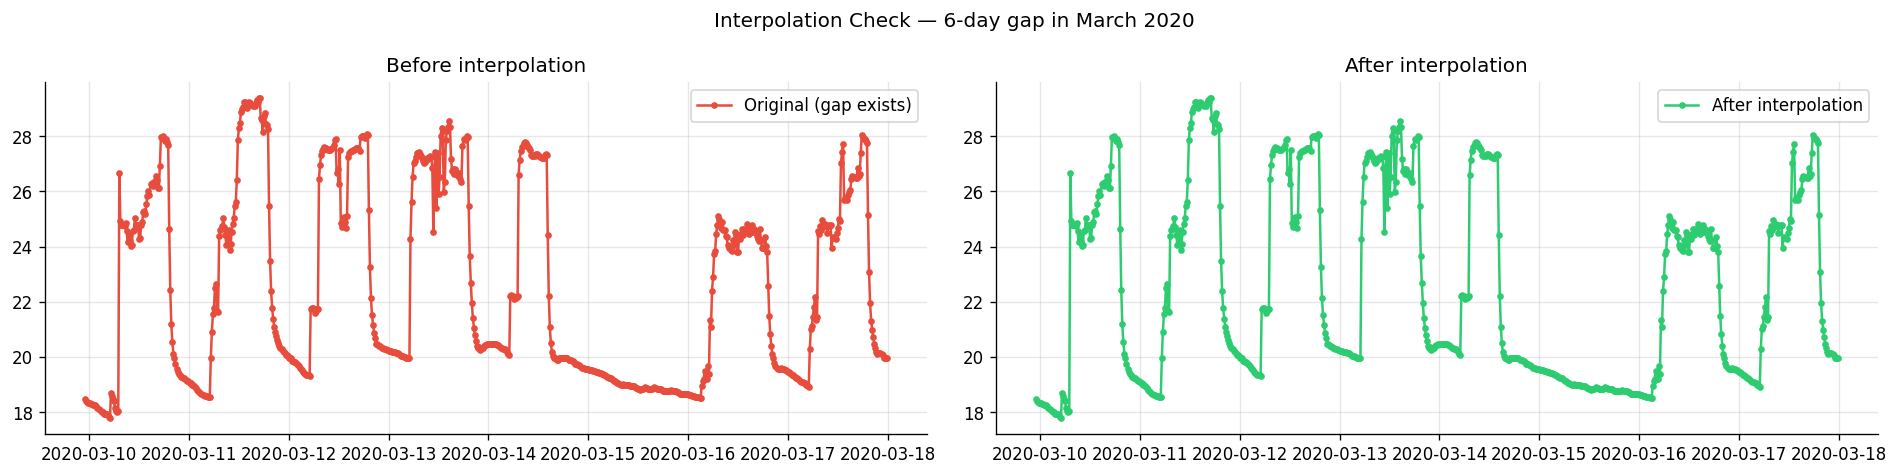

In [6]:
# Verify interpolation on the 6-day gap in March 2020
gap_region = slice('2020-03-07', '2020-03-17')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Interpolation Check — 6-day gap in March 2020', fontsize=12)

axes[0].plot(df['T_Supply'][gap_region], 'o-', markersize=3, color='#e74c3c', label='Original (gap exists)')
axes[0].set_title('Before interpolation'); axes[0].legend()

axes[1].plot(p1['T_Supply'][gap_region], 'o-', markersize=3, color='#2ecc71', label='After interpolation')
axes[1].set_title('After interpolation'); axes[1].legend()

plt.tight_layout()
plt.savefig('02_interpolation_check.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Min-Max Normalization
**Critical rule:** fit the scaler **only on Period 1 (train data)**, then apply to Period 2.  
This prevents data leakage — the model must not see Period 2 statistics during training.

In [7]:
# Fit on Period 1 only
P1_MIN = p1.min()
P1_MAX = p1.max()

def minmax_scale(df_in):
    return (df_in - P1_MIN) / (P1_MAX - P1_MIN + 1e-8)

p1_scaled = minmax_scale(p1)
p2_scaled = minmax_scale(p2)

print("Scaling parameters (from Period 1):")
scale_info = pd.DataFrame({'min': P1_MIN, 'max': P1_MAX,
                            'range': P1_MAX - P1_MIN})
print(scale_info.round(3).to_string())

print(f"\nP1 scaled — min: {p1_scaled.min().min():.3f}  max: {p1_scaled.max().max():.3f}")
print(f"P2 scaled — min: {p2_scaled.min().min():.3f}  max: {p2_scaled.max().max():.3f}")
print("(P2 may slightly exceed [0,1] — that's expected for anomalous periods)")

Scaling parameters (from Period 1):
              min     max   range
T_Supply   14.650  30.155  15.505
T_Return   15.020  24.770   9.750
T_Outdoor   3.400  32.800  29.400
Power       0.000   5.316   5.316
T_delta    -6.385   6.690  13.075

P1 scaled — min: 0.000  max: 1.000
P2 scaled — min: -0.274  max: 1.470
(P2 may slightly exceed [0,1] — that's expected for anomalous periods)


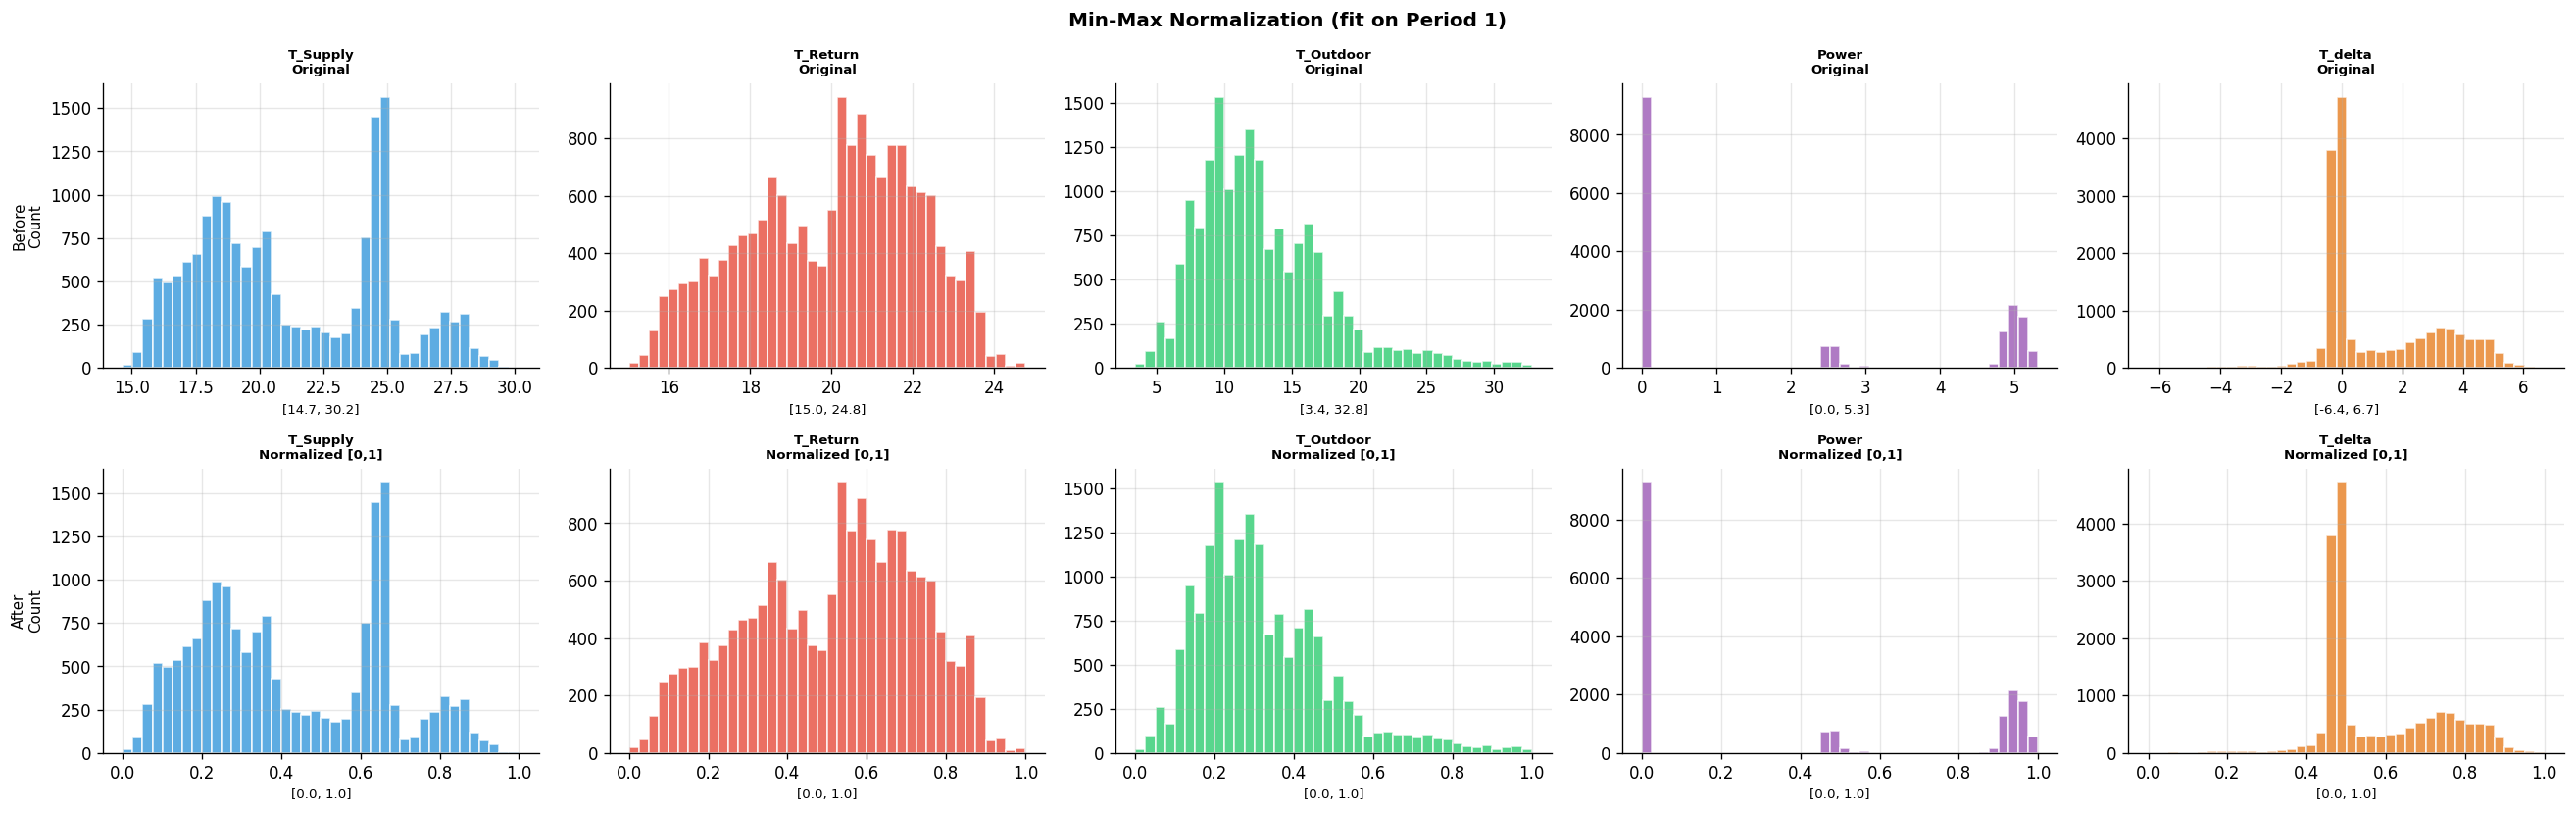

In [8]:
# Visualize before vs after normalization
fig, axes = plt.subplots(2, 5, figsize=(22, 7))
fig.suptitle('Min-Max Normalization (fit on Period 1)', fontsize=12, fontweight='bold')
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22']

for i, (col, c) in enumerate(zip(SELECTED, colors)):
    axes[0,i].hist(p1[col], bins=40, color=c, edgecolor='white', alpha=0.8)
    axes[0,i].set_title(f'{col}\nOriginal', fontsize=8, fontweight='bold')
    axes[0,i].set_xlabel(f'[{p1[col].min():.1f}, {p1[col].max():.1f}]', fontsize=8)

    axes[1,i].hist(p1_scaled[col], bins=40, color=c, edgecolor='white', alpha=0.8)
    axes[1,i].set_title(f'{col}\nNormalized [0,1]', fontsize=8, fontweight='bold')
    axes[1,i].set_xlabel('[0.0, 1.0]', fontsize=8)

axes[0,0].set_ylabel('Before\nCount', fontsize=9)
axes[1,0].set_ylabel('After\nCount', fontsize=9)
plt.tight_layout()
plt.savefig('03_normalization.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Sliding Window
Convert time series into overlapping windows for the model.

| Parameter | Value | Reason |
|---|---|---|
| Window size | **96 steps** | 24 hours — one full day of context |
| Slide step | **4 steps** | 1 hour — enough overlap, manageable size |
| Shape per window | **96 × 5** | (timesteps × features) |

In [9]:
WINDOW = 96   # 96 × 15min = 24 hours
STEP   = 4    # slide every 1 hour

def create_windows(df_scaled, window_size=WINDOW, step=STEP):
    data = df_scaled.values
    X, timestamps = [], []
    for i in range(0, len(data) - window_size + 1, step):
        X.append(data[i:i+window_size])
        timestamps.append(df_scaled.index[i + window_size - 1])
    return np.array(X, dtype=np.float32), timestamps

X_p1, ts_p1 = create_windows(p1_scaled)
X_p2, ts_p2 = create_windows(p2_scaled)

print(f"Each window shape : {WINDOW} steps × {len(SELECTED)} features")
print(f"X_p1 (Period 1)   : {X_p1.shape}")
print(f"X_p2 (Period 2)   : {X_p2.shape}")

Each window shape : 96 steps × 5 features
X_p1 (Period 1)   : (4208, 96, 5)
X_p2 (Period 2)   : (4238, 96, 5)


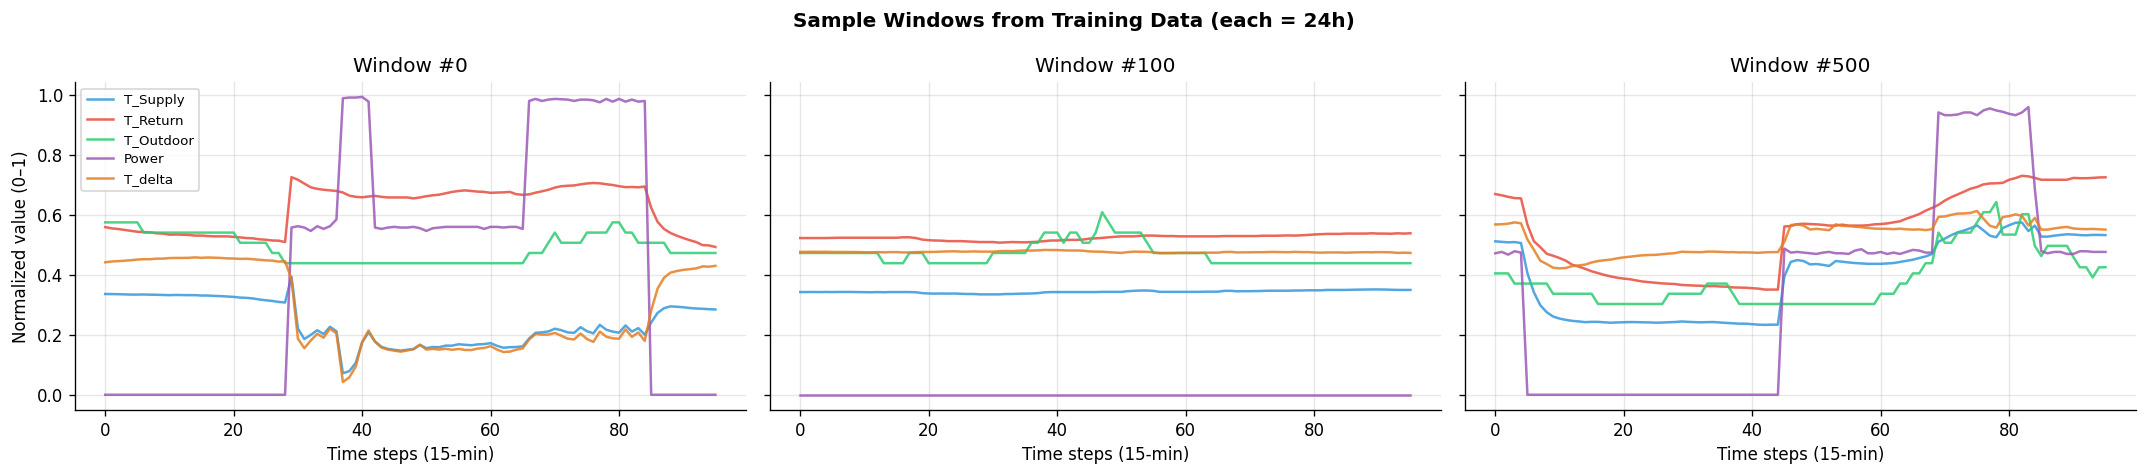

In [10]:
# Visualize 3 sample windows
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle('Sample Windows from Training Data (each = 24h)', fontsize=12, fontweight='bold')
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22']

for ax, wi in zip(axes, [0, 100, 500]):
    for fi, (feat, c) in enumerate(zip(SELECTED, colors)):
        ax.plot(X_p1[wi, :, fi], label=feat, color=c, linewidth=1.5, alpha=0.85)
    ax.set_title(f'Window #{wi}')
    ax.set_xlabel('Time steps (15-min)')
    if ax == axes[0]:
        ax.set_ylabel('Normalized value (0–1)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('04_sample_windows.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Train / Validation / Test Split

| Split | Data | Purpose |
|---|---|---|
| **Train (80%)** | Period 1 first 80% | Model learns what "normal" looks like |
| **Validation (20%)** | Period 1 last 20% | Tune anomaly threshold |
| **Test (100%)** | All of Period 2 | Evaluate — contains real anomalies (Jan 2021 spike) |

X_train : (3366, 96, 5)  ← model learns 'normal'
X_val   : (842, 96, 5)   ← threshold tuning
X_test  : (4238, 96, 5)  ← anomaly evaluation (Period 2)

Total windows: 8,446


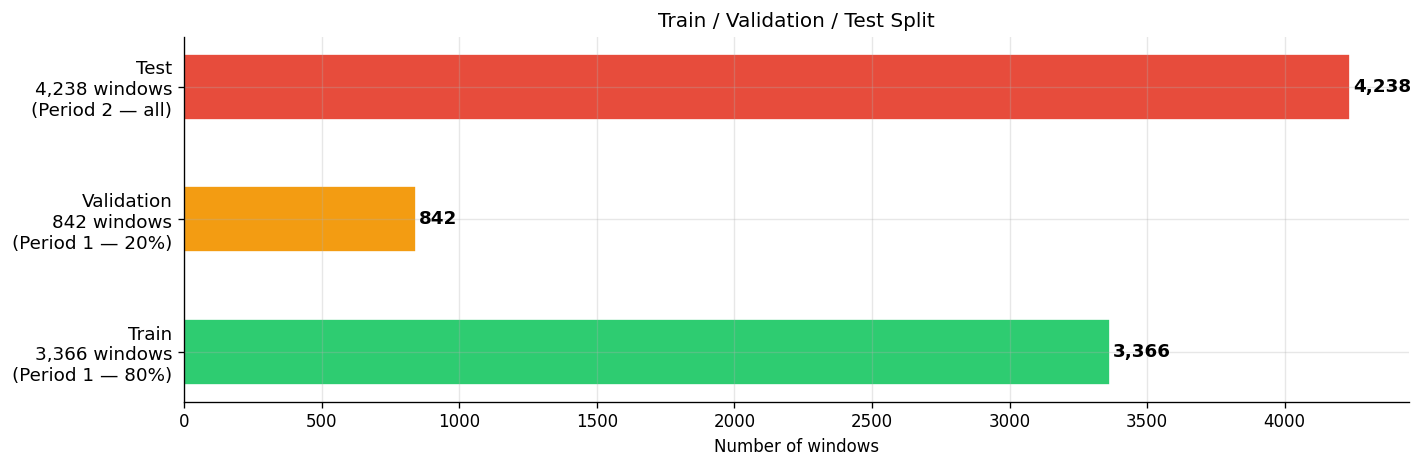

In [11]:
TRAIN_RATIO = 0.8
split_idx = int(len(X_p1) * TRAIN_RATIO)

X_train = X_p1[:split_idx]
X_val   = X_p1[split_idx:]
X_test  = X_p2
ts_test = ts_p2   # timestamps for anomaly visualization

print(f"X_train : {X_train.shape}  ← model learns 'normal'")
print(f"X_val   : {X_val.shape}   ← threshold tuning")
print(f"X_test  : {X_test.shape}  ← anomaly evaluation (Period 2)")
print(f"\nTotal windows: {len(X_train)+len(X_val)+len(X_test):,}")

# Split summary chart
fig, ax = plt.subplots(figsize=(12, 4))
sizes = [len(X_train), len(X_val), len(X_test)]
labels = [f'Train\n{len(X_train):,} windows\n(Period 1 — 80%)',
          f'Validation\n{len(X_val):,} windows\n(Period 1 — 20%)',
          f'Test\n{len(X_test):,} windows\n(Period 2 — all)']
colors_sp = ['#2ecc71','#f39c12','#e74c3c']
bars = ax.barh([0,1,2], sizes, color=colors_sp, edgecolor='white', height=0.5)
ax.set_yticks([0,1,2]); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Number of windows')
ax.set_title('Train / Validation / Test Split', fontsize=12)
for bar, v in zip(bars, sizes):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('05_train_val_test_split.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Save Preprocessed Data

In [12]:
import os
os.makedirs('preprocessed', exist_ok=True)

np.save('preprocessed/X_train.npy', X_train)
np.save('preprocessed/X_val.npy',   X_val)
np.save('preprocessed/X_test.npy',  X_test)
np.save('preprocessed/p1_min.npy',  P1_MIN.values)
np.save('preprocessed/p1_max.npy',  P1_MAX.values)
pd.Series(ts_test, name='timestamp').to_csv('preprocessed/test_timestamps.csv', index=False)

print("✅ Saved to ./preprocessed/")
print(f"  X_train.npy   : {X_train.shape}")
print(f"  X_val.npy     : {X_val.shape}")
print(f"  X_test.npy    : {X_test.shape}")
print(f"  p1_min/max    : scaling params")
print(f"  test_timestamps.csv : {len(ts_test)} timestamps")

✅ Saved to ./preprocessed/
  X_train.npy   : (3366, 96, 5)
  X_val.npy     : (842, 96, 5)
  X_test.npy    : (4238, 96, 5)
  p1_min/max    : scaling params
  test_timestamps.csv : 4238 timestamps


---
## ✅ Preprocessing Complete

| Step | What we did |
|---|---|
| **Feature selection** | T_Supply, T_Return, T_Outdoor, Power + engineered T_delta |
| **Gap handling** | Split at 183-day gap → 2 independent periods |
| **Reindex** | Filled to strict 15-min grid |
| **Interpolation** | Linear fill for gaps ≤ 2h (8 steps) |
| **Normalization** | Min-Max [0,1], scaler fit on Period 1 only |
| **Sliding window** | 96 steps (24h), stride 4 (1h) |
| **Split** | Train 80% / Val 20% (Period 1) + Test 100% (Period 2) |

**Known anomaly targets in test set:**
- Jan 2021: ΔT spike to +6°C (temperature control failure)
- Nov 2020: T_Supply volatility burst after restart (356 candidate points)

**Next → Step 3: LSTM Autoencoder model**